##### 실행 환경 설정

In [1]:
try:
    # Google Drive를 Colab에 마운트
    from google.colab import drive
    drive.mount('/google_drive')

    # 작업 경로 설정
    WORK_DIR = "/google_drive/Othercomputers/'내 컴퓨터'/sec07"
    print("\n[작업 폴더 목록]")
    %cd {WORK_DIR}
    !ls

    # 데이터셋 경로 설정
    DATASET_PATH = "/datasets/cifar10"
    !mkdir -p {DATASET_PATH}
    !cp -n {WORK_DIR}{DATASET_PATH}.zip {DATASET_PATH}.zip
    !unzip -qn {DATASET_PATH}.zip -d {DATASET_PATH}
    print("\n[데이터셋 폴더 목록]")
    print(DATASET_PATH)
    !ls {DATASET_PATH}
    print()

    # 한글 폰트 설치
    import matplotlib.pyplot as plt
    import matplotlib.font_manager as fm
    !apt-get -qq install fonts-nanum
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    plt.rcParams['font.family'] = 'NanumGothic'
    # 마이너스 기호 깨짐 방지
    plt.rcParams['axes.unicode_minus'] = False
except Exception:
    # 데이터셋 경로 설정
    DATASET_PATH = "../datasets/cifar10"

    # 로컬 dataset 폴더 접근 확인
    import os
    print("\n[데이터셋 폴더 목록]")
    print(f"{DATASET_PATH}")
    for dir in os.listdir(DATASET_PATH):
        print(dir, end='  ')

    # 한글 폰트 설정
    import matplotlib.pyplot as plt
    plt.rcParams['font.family'] = 'Malgun Gothic'
    # 마이너스 기호 깨짐 방지
    plt.rcParams['axes.unicode_minus'] = False

Mounted at /google_drive

[작업 폴더 목록]
/google_drive/Othercomputers/내 컴퓨터/sec07
01_dataset_dataloader.ipynb  07_transfer_learning_resnet.ipynb
02_cnn_model.ipynb	     08_transfer_learning_efficientnet.ipynb
03_train.ipynb		     datasets
04_cnn_model_gap.ipynb	     saved_models_data_augmentation
05_train_gap.ipynb	     saved_models_efficientnet
06_data_augmentation.ipynb   saved_models_resnet

[데이터셋 폴더 목록]
/datasets/cifar10
test  train  val

Selecting previously unselected package fonts-nanum.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


##### 임포트

In [2]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import Dataset, DataLoader
import copy
import os

##### Device 설정

In [3]:
# GPU(CUDA) 사용 가능 시 'cuda', 아니면 'cpu' 사용
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 장치: {device}")

사용 장치: cuda


##### RGB 평균/표준편차 계산 함수

In [4]:
# def calculate_mean_std(path:str):
#     """훈련 데이터셋의 채널별(RGB)평균/표준편차를 계산하는 함수"""
#     # Dataset 생성
#     train_dataset = datasets.ImageFolder(
#         path,
#         transform=transforms.ToTensor()   # 픽셀값을 0~1 범위로 스케일 변환만 적용
#     )

#     # 배치 단위로 데이터를 불러오기 위해 DataLoader 생성
#     train_loader = DataLoader(train_dataset, batch_size=512, shuffle=False)

#     # 채널별 누적합을 저장할 Tensor 초기화
#     channel_sum    = torch.zeros(3)

#     # 채널별 제곱 누적합을 저장할 Tensor 초기화
#     channel_sum_sq = torch.zeros(3)

#     # 전체 픽셀 수를 저장할 변수 초기화
#     pixel_count    = 0

#     # DataLoader로 배치 단위로 데이터를 불러옴
#     for images, _ in train_loader:
#         # images shape: (batch, 3, 32, 32)
#         channel_sum    += images.sum(dim=[0, 2, 3])      # 배치·높이·너비 방향 합산
#         channel_sum_sq += (images ** 2).sum(dim=[0, 2, 3])
#         pixel_count    += images.shape[0] * images.shape[2] * images.shape[3]

#     # 채널별 평균과 표준편차 계산
#     mean = channel_sum / pixel_count                         # tensor shape: (3,)
#     std  = (channel_sum_sq / pixel_count - mean ** 2).sqrt() # tensor shape: (3,)

#     return mean.tolist(), std.tolist()

# # 훈련 데이터셋의 채널별 평균과 표준편차 계산
# mean, std = calculate_mean_std("data/cifar10/train")
# print("CIFAR-10 훈련 데이터셋의 채널별 평균:", mean)
# print("CIFAR-10 훈련 데이터셋의 채널별 표준편차:", std)

# CIFAR-10 훈련 데이터셋의 채널별 평균: [0.491350919008255, 0.48206818103790283, 0.4465498626232147]
# CIFAR-10 훈련 데이터셋의 채널별 표준편차: [0.24713236093521118, 0.2436210662126541, 0.2617213726043701]

##### Transform 정의(데이터 증강 포함)

In [5]:
# 앞에서 계산한 mean, std를 튜플로 변환해 사용
# RGB_MEAN = tuple(mean)  # R, G, B 채널 평균
# RGB_STD  = tuple(std)   # R, G, B 채널 표준편차

RGB_MEAN = (0.491350919008255, 0.48206818103790283, 0.4465498626232147)   # R, G, B 채널 평균
RGB_STD  = (0.24713236093521118, 0.2436210662126541, 0.2617213726043701)  # R, G, B 채널 표준편차

# 훈령용 전처리 파이프라인 정의
# - 데이터 증강을 적용하여 모델 일반화 성능 향상
train_transform = transforms.Compose([
    transforms.Resize(224), # ResNet은 ImageNet(224×224)으로 사전 학습된 모델이므로, CIFAR-10(32×32)을 224×224로 업스케일
    transforms.RandomHorizontalFlip(),      # 50% 확률로 좌우 반전
    transforms.ToTensor(), # PIL Image (H, W, C) -> Tensor (C, H, W) float32 0.0 ~ 1.0 로 변환
    transforms.Normalize(RGB_MEAN, RGB_STD) # 채널별로 표준화된 데이터로 변환
])

# 검증/테스트용 전처리 파이프라인 정의
# - 증강 없이 적용
val_test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(RGB_MEAN, RGB_STD),
])

##### 훈련/검증/테스트별로 Dataset 생성  

In [6]:
# ImageFolder를 이용해서 Dataset 생성
train_dataset = datasets.ImageFolder(DATASET_PATH + "/train", transform=train_transform)
val_dataset   = datasets.ImageFolder(DATASET_PATH + "/val",   transform=val_test_transform)
test_dataset  = datasets.ImageFolder(DATASET_PATH + "/test",  transform=val_test_transform)

print(f"학습 데이터셋 크기  : {len(train_dataset):5d} 개")
print(f"검증 데이터셋 크기  : {len(val_dataset):5d} 개")
print(f"테스트 데이터셋 크기: {len(test_dataset):5d} 개")
print(f"클래스 목록: {train_dataset.classes}")
print(f"클래스 인덱스: {train_dataset.class_to_idx}")

학습 데이터셋 크기  : 45000 개
검증 데이터셋 크기  :  5000 개
테스트 데이터셋 크기: 10000 개
클래스 목록: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
클래스 인덱스: {'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


##### 훈련/검증/테스트별로 DataLoader 생성

In [7]:
# 배치 크기 설정
# - 작을 수록(16~32): 일반화 성능 UP, 과적합 방지에 유리, 학습 속도 Down, GPU를 충분히 활용하지 못함
# - 클수록(128~512): 일반화 성능 Down, 과적합 발생 증가 가능, 학습 속도 UP, GPU를 충분히 활용
# - 64: GPU 메모리 사용량과 학습 속도, 일반화 성능을 적절히 고려한 값으로, 대부분의 경우 적절한 선택
BATCH_SIZE  = 64

# DataLoader에서 데이터를 불러올 때 사용할 워커(worker) 수
# 무료 코랩은 보통 CPU 2코어 제공. 코어 수보다 많은 worker는 효과 없고 오히려 오버헤드 발생
NUM_WORKERS = 2

# 훈련용 DataLoader 생성
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,  # 매 에포크마다 순서를 섞어 과적합 방지
    num_workers=NUM_WORKERS,
)

# 검증용 DataLoader 생성
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,  # 검증/테스트는 순서 고정
    num_workers=NUM_WORKERS,
)

# 테스트용 DataLoader 생성
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,  # 검증/테스트는 순서 고정
    num_workers=NUM_WORKERS,
)

print(f"train 배치 수: {len(train_loader)}")   # 45000 / 64 = 704
print(f"val   배치 수: {len(val_loader)}")     # 5000  / 64 = 79
print(f"test  배치 수: {len(test_loader)}")    # 10000 / 64 = 157


train 배치 수: 704
val   배치 수: 79
test  배치 수: 157


##### 배치 데이터 확인

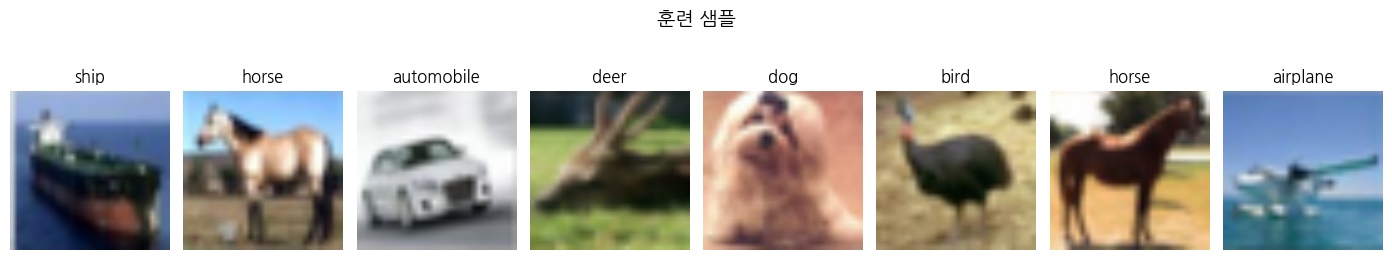

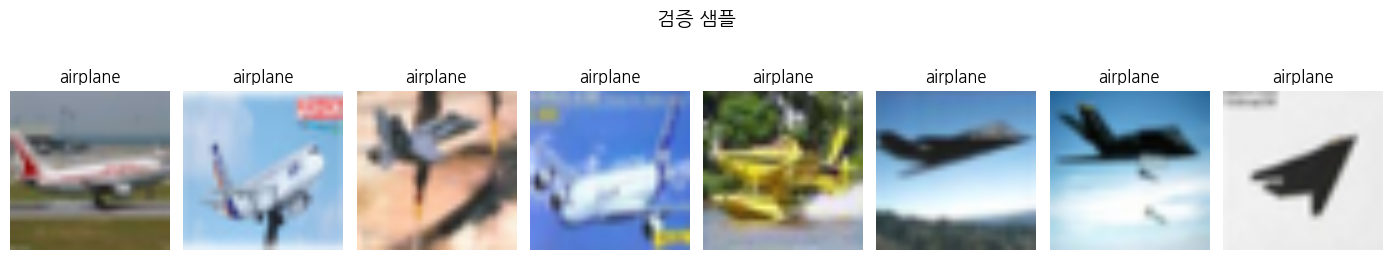

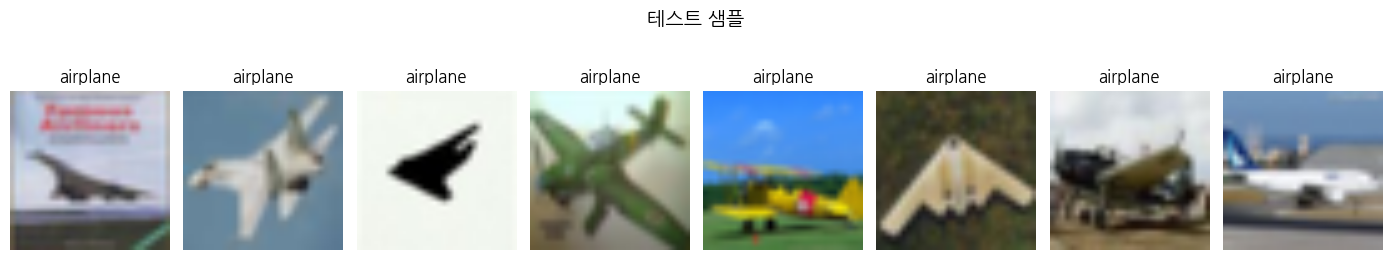

In [8]:
# DataLoader에서 배치 단위로 샘플 이미지를 시각화하는 함수
def show_batch_sample(title:str, dataset:Dataset, loader:DataLoader, rgb_mean:tuple, rgb_std:tuple):
    # DataLoader에서 첫 번째 배치 꺼내기
    # images: (batch_size, 3, 32, 32) 형태의 Tensor
    # labels: (batch_size,) 형태의 Tensor
    images, labels = next(iter(loader))

    # 배치에서 샘플 이미지 8장을 보여줄 서브 플롯 생성
    fig, axes = plt.subplots(1, 8, figsize=(14, 3))
    fig.suptitle(title, fontsize=14)

    # view(3, 1, 1): 브로드캐스팅을 위해 (3,) → (3, 1, 1) 형태로 변환
    mean = torch.tensor(rgb_mean).view(3, 1, 1)
    std  = torch.tensor(rgb_std).view(3, 1, 1)

    # images[:8]: 배치에서 처음 8장 이미지 선택 (shape: (8, 3, 32, 32))
    for ax, img, lbl in zip(axes, images[:8], labels[:8]):
        # DataLoader로 불러온 이미지는 이미 표준화된 상태이므로, 시각화를 위해 표준화 역변환을 수행
        # 표준화 역변환: (표준화된 값 × std) + mean
        img_display = img * std + mean
        # 픽셀값을 0~1 범위로 클리핑 (표준화 역변환 후 범위를 벗어나는 값 보정)
        # -0.05  →  0.0   (하한 보정)
        #  0.53  →  0.53  (그대로)
        #  1.02  →  1.0   (상한 보정)
        img_display = img_display.clamp(0, 1)   # 픽셀값을 0~1 범위로 클램프
        # (C, H, W) → (H, W, C)
        img_display = img_display.permute(1, 2, 0).numpy()  # (C, H, W) → (H, W, C)

        ax.imshow(img_display)
        ax.set_title(dataset.classes[lbl], fontsize=12)
        ax.axis("off")

    plt.tight_layout(pad=1)
    plt.show()

show_batch_sample("훈련 샘플", train_dataset, train_loader, RGB_MEAN, RGB_STD)
show_batch_sample("검증 샘플", val_dataset, val_loader, RGB_MEAN, RGB_STD)
show_batch_sample("테스트 샘플", test_dataset, test_loader, RGB_MEAN, RGB_STD)


##### 전이 학습을 위한 모델 로딩 및 설정

In [9]:
# 사전 학습된 EfficientNet-B0 불러오기
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# EfficientNet-B0의 마지막 fc 분류 레이어 교체: classifier[1] Linear(1280, 1000) → Linear(1280, 10)
# - model.classifier[1].in_features: 1280 (EfficientNet-B0의 fc 레이어에 입력되는 GPA 특징 수, avgpool 출력 채널 수, 고정값)
# - CIFAR-10 클래스 수: 10
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 10)

# 모델을 디바이스로 이동
model = model.to(device)
print(model, "\n")

# 모델 파라미터 수 확인
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"전체 파라미터 수         : {total_params:,}")
print(f"학습 가능 파라미터 수     : {trainable_params:,}")
print(f"교체된 classifier[1]    : {model.classifier[1]}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 70.9MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

##### 손실 함수와 옵티마이저 생성

In [10]:
# 손실 함수: 다중 분류에 표준적으로 사용되는 CrossEntropyLoss
# - 내부적으로 Softmax 적용됨
# - 입력: 모델 출력 logit (batch, 10), 정답 레이블 (batch,)
loss_fn = nn.CrossEntropyLoss()

# 옵티마이저 생성
# 파인튜닝: 두 파라미터 그룹으로 분리해 학습률 차등 적용
# - classifier (새로 초기화된 레이어): 높은 lr로 빠르게 학습
# - 나머지 레이어 (사전 학습된 레이어): 낮은 lr로 기존 특징 유지하며 미세 조정
optimizer = torch.optim.Adam([
    {"params": model.classifier.parameters(), "lr": 1e-3},
    {"params": [p for n, p in model.named_parameters() if "classifier" not in n], "lr": 1e-4},
])

##### 학습률 스케쥴러 설정 및 EarlyStopping 설정

In [11]:
# LR 스케줄러: 검증 손실이 patience 에포크 동안 개선되지 않으면 lr을 factor 배만큼 줄임
# mode='min': 손실이 낮을수록 좋음 / factor=0.5: lr을 절반으로 감소 / patience=3: 3 에포크 기다림
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# 조기 종료(Early Stopping) 설정
# - patience: 검증 손실이 개선되지 않아도 허용할 에포크 수
# - patience_counter: 개선 없이 누적된 에포크 수
# - best_val_loss: 현재까지 가장 낮은 검증 손실 (초기값: 양의 무한대)
# - best_model_state: 검증 손실이 가장 낮았을 때의 모델 파라미터 복사본
PATIENCE         = 5  # 전이 학습은 수렴이 빠르므로 수를 줄여도 충분히 좋은 성능을 낼 수 있음
patience_counter = 0
best_val_loss    = float('inf')
best_model_state = None

##### 학습 함수 정의

In [12]:
def train(loader):
    """한 에포크 학습: 전체 훈련 데이터를 한 번 순회하며 파라미터 업데이트"""
    model.train()  # 학습 모드: Dropout 동작

    total_loss    = 0.0
    correct       = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device)         # 이미지 배치 데이터를 디바이스로 이동
        labels = labels.to(device)         # 레이블 배치 데이터를 디바이스로 이동

        optimizer.zero_grad()              # 이전 배치의 gradient 초기화
        outputs = model(images)            # 순전파: (batch, 10) 로짓 출력
        loss = loss_fn(outputs, labels)    # 손실 계산
        loss.backward()                    # 역전파: gradient 계산
        optimizer.step()                   # 파라미터 업데이트

        total_loss    += loss.item() * images.size(0)  # 배치 내 샘플 평균 손실 x 배치 크기
        predicted      = outputs.argmax(dim=1)         # 가장 높은 로짓의 인덱스 = 예측 클래스
        correct       += (predicted == labels).sum().item()
        total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    accuracy = correct / total_samples * 100
    return avg_loss, accuracy

##### 검증 함수 정의

In [13]:
def evaluate(loader):
    """검증/테스트 평가: gradient 계산 없이 손실과 정확도만 측정"""
    model.eval()  # 평가 모드: Dropout 비활성화

    total_loss    = 0.0
    correct       = 0
    total_samples = 0

    with torch.no_grad():  # gradient 계산 비활성화 → 메모리 절약, 속도 향상
        for images, labels in loader:
            images  = images.to(device)
            labels  = labels.to(device)

            outputs = model(images)
            loss    = loss_fn(outputs, labels)

            total_loss    += loss.item() * images.size(0)
            predicted      = outputs.argmax(dim=1)
            correct       += (predicted == labels).sum().item()
            total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    accuracy = correct / total_samples * 100
    return avg_loss, accuracy


##### 학습하기

In [14]:
# 전이 학습은 수렴이 빠르므로 에포크 수를 줄여도 충분히 좋은 성능을 낼 수 있음
NUM_EPOCHS = 30

# 학습 곡선 시각화를 위한 학습/검증 손실과 정확도 기록용 딕셔너리
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss":   [],
    "val_acc":   [],
}

# 학습 루프
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train(train_loader)
    val_loss,   val_acc   = evaluate(val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    scheduler.step(val_loss)
    fc_lr    = optimizer.param_groups[0]["lr"]
    other_lr = optimizer.param_groups[1]["lr"]

    print(f"Epoch [{epoch:3d}/{NUM_EPOCHS}]  "
          f"훈련 손실: {train_loss:.4f}  훈련 정확도: {train_acc:5.1f}%  "
          f"검증 손실: {val_loss:.4f}  검증 정확도: {val_acc:5.1f}%  "
          f"lr(fc): {fc_lr:.2e}  lr(기타): {other_lr:.2e}", end="")

    # 조기 종료 판단
    if val_loss < best_val_loss:
        # 검증 손실이 개선된 경우: 최적 상태 갱신
        best_val_loss    = val_loss
        patience_counter = 0
        # 현재 에포크의 모델 파라미터를 별도 메모리에 완전히 복사
        best_model_state = copy.deepcopy(model.state_dict())
        print("  ✓ 최적 모델 저장")
    else:
        # 검증 손실이 개선되지 않은 경우: 카운터 증가
        patience_counter += 1
        print(f"  (개선 없음 {patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\n조기 종료: {PATIENCE} 에포크 동안 검증 손실 개선 없음")
            break

model.load_state_dict(best_model_state)
print(f"\n학습 완료  (최적 검증 손실: {best_val_loss:.4f})")


Epoch [  1/30]  훈련 손실: 0.3645  훈련 정확도:  88.2%  검증 손실: 0.1241  검증 정확도:  95.7%  lr(fc): 1.00e-03  lr(기타): 1.00e-04  ✓ 최적 모델 저장
Epoch [  2/30]  훈련 손실: 0.1377  훈련 정확도:  95.2%  검증 손실: 0.0964  검증 정확도:  96.6%  lr(fc): 1.00e-03  lr(기타): 1.00e-04  ✓ 최적 모델 저장
Epoch [  3/30]  훈련 손실: 0.0836  훈련 정확도:  97.1%  검증 손실: 0.0961  검증 정확도:  96.7%  lr(fc): 1.00e-03  lr(기타): 1.00e-04  ✓ 최적 모델 저장
Epoch [  4/30]  훈련 손실: 0.0593  훈련 정확도:  97.9%  검증 손실: 0.0879  검증 정확도:  97.1%  lr(fc): 1.00e-03  lr(기타): 1.00e-04  ✓ 최적 모델 저장
Epoch [  5/30]  훈련 손실: 0.0456  훈련 정확도:  98.5%  검증 손실: 0.1063  검증 정확도:  96.8%  lr(fc): 1.00e-03  lr(기타): 1.00e-04  (개선 없음 1/5)
Epoch [  6/30]  훈련 손실: 0.0403  훈련 정확도:  98.6%  검증 손실: 0.1133  검증 정확도:  96.8%  lr(fc): 1.00e-03  lr(기타): 1.00e-04  (개선 없음 2/5)
Epoch [  7/30]  훈련 손실: 0.0342  훈련 정확도:  98.8%  검증 손실: 0.0986  검증 정확도:  97.1%  lr(fc): 1.00e-03  lr(기타): 1.00e-04  (개선 없음 3/5)
Epoch [  8/30]  훈련 손실: 0.0282  훈련 정확도:  99.1%  검증 손실: 0.1033  검증 정확도:  97.0%  lr(fc): 5.00e-04  lr(기타): 5.00e-05  (개선 없음 4

학습 곡선 시각화

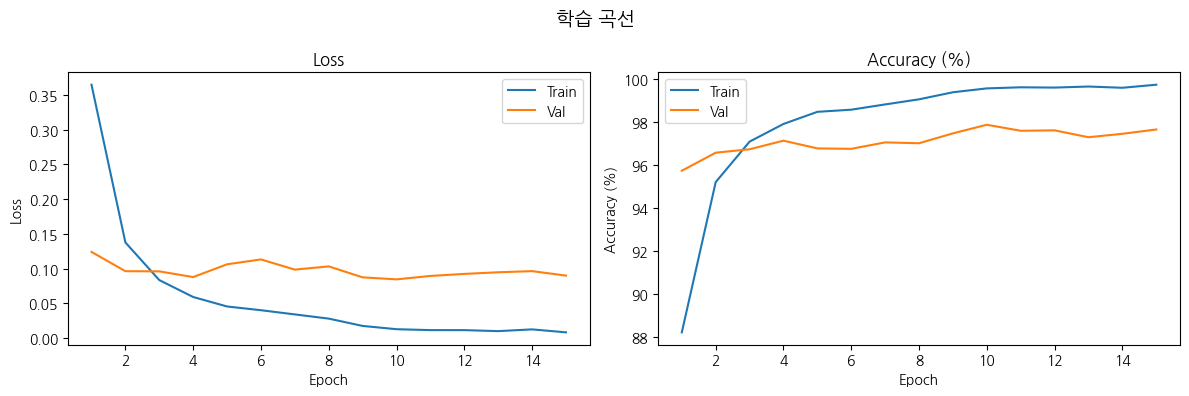

In [15]:
# 실제 학습된 에포크 수 기준으로 x축 생성 (조기 종료 시 NUM_EPOCHS보다 작을 수 있음)
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("학습 곡선", fontsize=14, fontweight="bold")

# 손실 곡선
axes[0].plot(epochs, history["train_loss"], label="Train")
axes[0].plot(epochs, history["val_loss"],   label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# 정확도 곡선
axes[1].plot(epochs, history["train_acc"], label="Train")
axes[1].plot(epochs, history["val_acc"],   label="Val")
axes[1].set_title("Accuracy (%)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()

plt.tight_layout()
plt.show()


##### 테스트 평가

In [16]:
test_loss, test_acc = evaluate(test_loader)
print(f"Test Loss: {test_loss:.4f}  |  Test Accuracy: {test_acc:.2f}%")


Test Loss: 0.1288  |  Test Accuracy: 96.91%


##### 모델 저장

In [17]:
# 모델이 저장될 디렉토리 (존재하지 않으면 생성)
SAVE_DIR = "saved_models_efficientnet"
os.makedirs(SAVE_DIR, exist_ok=True)

# 모델 구조와 파라미터를 함께 저장
full_path = os.path.join(SAVE_DIR, 'cifar10_classifier_full.pt')
torch.save(model, full_path)
print(f"✓ 전체 모델 저장 완료: {full_path}")

✓ 전체 모델 저장 완료: saved_models_efficientnet/cifar10_classifier_full.pt


저장된 모델로 예측

In [18]:
# full.pt 파일을 이용
pt_path = os.path.join(SAVE_DIR, 'cifar10_classifier_full.pt')
loaded_model = torch.load(pt_path, map_location=device, weights_only=False)

# 모델을 평가 모드로 전환 (Dropout 비활성화)
loaded_model.eval()

# 테스트셋 첫 번째 샘플 얻기
image, label = test_dataset[0]

# 모델 입력 형태로 변환 (배치 차원 추가) 후 디바이스로 이동
input_tensor = image.unsqueeze(0).to(device)  # (1, C, H, W)

# 예측 수행 (gradient 계산 비활성화)
with torch.inference_mode():
    output   = loaded_model(input_tensor)
    pred_idx = output.argmax(dim=1).item()

# 클래스 이름 목록 (예측 결과 해석용)
CLASS_NAMES = test_dataset.classes
print(f"예측 클래스: {CLASS_NAMES[pred_idx]}")
print(f"실제 클래스: {CLASS_NAMES[label]}")

예측 클래스: airplane
실제 클래스: airplane
